# EIT Transcription Pipeline
## Automatic Speech Recognition for Elicited Imitation Task Responses

This notebook transcribes the segmented response WAV files produced by the **v3 segmentation pipeline**.

### Backend Selection (macOS)

| Backend | Best for | Speed | Notes |
|---|---|---|---|
| **MLX Whisper** | Apple Silicon (M1/M2/M3/M4) | ⚡⚡⚡ Fastest | Uses Apple Neural Engine + GPU via MLX |
| **whisper.cpp** | Intel Mac or Apple Silicon | ⚡⚡ Fast | Native C++ inference, no Python overhead |
| **OpenAI Whisper** | Universal fallback | ⚡ Moderate | Pure PyTorch, works everywhere |

The notebook **auto-detects** your chip and selects the fastest available backend. You can override with `BACKEND` in Section 2.

### Pipeline
```
segments.csv (from v3)  →  Load segment metadata
                        →  Backend selection & model load
                        →  Per-segment ASR (Spanish, large-v3)
                        →  Text normalization
                        →  WER / CER vs. stimulus sentence
                        →  Results CSV + XLSX
                        →  Visualization
```

---
## Section 1 — Environment Detection & Package Installation

In [1]:
import subprocess, sys, platform, os

# ── Detect chip ──────────────────────────────────────────────────────────
def get_mac_chip():
    """Returns 'apple_silicon', 'intel', or 'other'."""
    if platform.system() != 'Darwin':
        return 'other'
    try:
        result = subprocess.run(
            ['sysctl', '-n', 'machdep.cpu.brand_string'],
            capture_output=True, text=True
        )
        brand = result.stdout.strip()
        if 'Apple' in brand:
            return 'apple_silicon'
        return 'intel'
    except Exception:
        # Fallback: check processor
        proc = platform.processor()
        return 'apple_silicon' if 'arm' in proc.lower() else 'intel'


CHIP = get_mac_chip()
print(f"Platform  : {platform.system()} {platform.release()}")
print(f"Chip type : {CHIP}")
print(f"Python    : {sys.version.split()[0]}")
print()

# ── Install common dependencies ──────────────────────────────────────────
common_pkgs = ["numpy", "pandas", "matplotlib", "soundfile",
               "librosa", "tqdm", "openpyxl", "jiwer", "unicodedata2"]
print("Installing common packages...")
for pkg in common_pkgs:
    r = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                       capture_output=True)
    print(f"  {'OK' if r.returncode==0 else 'WARN'} {pkg}")

# ── Install backend packages based on chip ───────────────────────────────
print()
if CHIP == 'apple_silicon':
    print("Apple Silicon detected — installing MLX Whisper (primary) + whisper.cpp (fallback)...")
    backend_pkgs = ["mlx-whisper", "pywhispercpp"]
else:
    print("Intel Mac detected — installing whisper.cpp (primary) + openai-whisper (fallback)...")
    backend_pkgs = ["pywhispercpp", "openai-whisper"]

for pkg in backend_pkgs:
    r = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                       capture_output=True)
    print(f"  {'OK' if r.returncode==0 else 'WARN'} {pkg}")

print("\nInstallation complete.")

Platform  : Darwin 25.0.0
Chip type : apple_silicon
Python    : 3.11.15

Installing common packages...
  OK numpy
  OK pandas
  OK matplotlib
  OK soundfile
  OK librosa
  OK tqdm
  OK openpyxl
  OK jiwer
  OK unicodedata2

Apple Silicon detected — installing MLX Whisper (primary) + whisper.cpp (fallback)...
  OK mlx-whisper
  OK pywhispercpp

Installation complete.


In [2]:
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, unicodedata, re, time, json
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
print("Core imports OK")

Core imports OK


---
## Section 2 — Configuration

> **`BACKEND` options**: `'auto'` (recommended), `'mlx'`, `'whispercpp'`, `'openai'`  
> **`MODEL_SIZE`**: `'large-v3'` (default, best accuracy), `'medium'`, `'small'`  
> **`LANGUAGE`**: `'es'` for Spanish (forces Spanish decoding, prevents language confusion)

In [3]:
# ── Segmentation output from v3 pipeline ────────────────────────────────
# Point this to the segments.csv from the v3 segmentation notebook
SEGMENTS_CSV = "eit_output_v3/038012_2A_preprocessed/segments.csv"

# Process multiple recordings by adding more entries:
# SEGMENTS_CSV_LIST = [
#     "eit_output_v3/038015_1A_preprocessed/segments.csv",
#     "eit_output_v3/038012_2A_preprocessed/segments.csv",
#     ...
# ]

# ── Whisper configuration ────────────────────────────────────────────────
BACKEND    = 'auto'        # 'auto' | 'mlx' | 'whispercpp' | 'openai'
MODEL_SIZE = 'large-v3'    # 'large-v3' | 'large-v2' | 'medium' | 'small'
LANGUAGE   = 'es'          # ISO 639-1 language code for Spanish

# ── Decoding parameters ──────────────────────────────────────────────────
# BEAM_SIZE         = 5      # Beam search width (higher = better but slower)
BEAM_SIZE = None
TEMPERATURE       = 0.0    # 0.0 = greedy (deterministic); raise to 0.2 for variety
CONDITION_ON_PREV = False  # Don't condition on previous segment (independent clips)
WORD_TIMESTAMPS   = True   # Request word-level timestamps where supported
NO_SPEECH_THRESH  = 0.6    # Probability above which segment is marked as silence

# ── Audio preprocessing for ASR ─────────────────────────────────────────
ASR_SR            = 16000  # Whisper always expects 16 kHz
AUDIO_PAD_S       = 0.1    # Seconds of silence padding at start/end of each clip

# ── Output ───────────────────────────────────────────────────────────────
# Auto-derived from SEGMENTS_CSV location
OUTPUT_DIR = Path(SEGMENTS_CSV).parent / "transcriptions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Segments CSV  : {SEGMENTS_CSV}")
print(f"Backend       : {BACKEND}")
print(f"Model         : whisper-{MODEL_SIZE}")
print(f"Language      : {LANGUAGE}")
print(f"Output dir    : {OUTPUT_DIR}")

Segments CSV  : eit_output_v3/038012_2A_preprocessed/segments.csv
Backend       : auto
Model         : whisper-large-v3
Language      : es
Output dir    : eit_output_v3/038012_2A_preprocessed/transcriptions


---
## Section 3 — Load Segment Metadata

Read the `segments.csv` produced by the v3 segmentation pipeline. This tells us:
- Which stimulus each response corresponds to
- Where the response WAV file is
- Whether the response is MISSING

In [4]:
def load_segments(csv_path):
    """Load and validate segments CSV from v3 pipeline."""
    assert os.path.exists(csv_path), f"segments.csv not found: {csv_path}"
    df = pd.read_csv(csv_path)

    required_cols = ['stimulus_id', 'stimulus_text', 'response_start',
                     'response_end', 'response_duration', 'status', 'response_file']
    missing_cols  = [c for c in required_cols if c not in df.columns]
    assert not missing_cols, f"Missing columns in CSV: {missing_cols}"

    print(f"Loaded: {csv_path}")
    print(f"  Total rows     : {len(df)}")
    print(f"  Responses OK   : {(df['status']=='OK').sum()}")
    print(f"  Missing        : {(df['status']=='MISSING').sum()}")
    return df


segments_df = load_segments(SEGMENTS_CSV)

# Separate transcribable from missing
to_transcribe = segments_df[segments_df['status'] == 'OK'].copy().reset_index(drop=True)
missing_segs  = segments_df[segments_df['status'] == 'MISSING'].copy()

print(f"\nWill transcribe: {len(to_transcribe)} response segments")
display(segments_df[['stimulus_id','stimulus_text','response_start',
                       'response_end','response_duration','status']].head(10))

Loaded: eit_output_v3/038012_2A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0

Will transcribe: 30 response segments


,stimulus_id,stimulus_text,response_start,response_end,response_duration,status
0,1,Quiero cortarme el pelo,2.9,4.2,1.3,OK
1,2,El libro está en la mesa,10.0,11.7,1.7,OK
2,3,El carro lo tiene Pedro,17.4,19.0,1.6,OK
3,4,El se ducha cada mañana,25.2,27.0,1.8,OK
4,5,¿Qué dice usted que va a hacer hoy?,34.5,36.3,1.8,OK
5,6,Dudo que sepa manejar muy bien,43.5,47.4,3.9,OK
6,7,Las calles de esta ciudad son muy anchas,53.7,59.9,6.2,OK
7,8,Puede que llueva mañana todo el día,65.3,67.6,2.3,OK
8,9,Las casas son muy bonitas pero caras,76.1,78.4,2.3,OK
9,10,Me gustan las películas que acaban bien,87.7,90.8,3.1,OK


---
## Section 4 — Backend Selection & Model Loading

Selects and loads the fastest available Whisper backend for your machine.

In [5]:
# ── Backend availability checks ──────────────────────────────────────────
def check_mlx():
    try:
        import mlx_whisper
        return True
    except ImportError:
        return False


def check_whispercpp():
    try:
        from pywhispercpp.model import Model
        return True
    except ImportError:
        return False


def check_openai_whisper():
    try:
        import whisper
        return True
    except ImportError:
        return False


avail = {
    'mlx'       : check_mlx(),
    'whispercpp': check_whispercpp(),
    'openai'    : check_openai_whisper(),
}
print("Backend availability:")
for k, v in avail.items():
    print(f"  {k:<12}: {'✓ available' if v else '✗ not installed'}")


# ── Auto-select ──────────────────────────────────────────────────────────
def resolve_backend(requested, chip, availability):
    if requested != 'auto':
        assert availability.get(requested), \
            f"Backend '{requested}' requested but not installed."
        return requested
    # Priority order
    if chip == 'apple_silicon' and availability['mlx']:
        return 'mlx'
    if availability['whispercpp']:
        return 'whispercpp'
    if availability['openai']:
        return 'openai'
    raise RuntimeError("No Whisper backend available. Run Section 1 again.")


ACTIVE_BACKEND = resolve_backend(BACKEND, CHIP, avail)
print(f"\nSelected backend: {ACTIVE_BACKEND}")

Backend availability:
  mlx         : ✓ available
  whispercpp  : ✓ available
  openai      : ✗ not installed

Selected backend: mlx


In [6]:
# ── MLX Whisper model IDs ────────────────────────────────────────────────
# MLX models are hosted on HuggingFace under mlx-community/
MLX_MODEL_MAP = {
    'large-v3': 'mlx-community/whisper-large-v3-mlx',
    'large-v2': 'mlx-community/whisper-large-v2-mlx',
    'medium'  : 'mlx-community/whisper-medium-mlx',
    'small'   : 'mlx-community/whisper-small-mlx',
}

# ── whisper.cpp model names ──────────────────────────────────────────────
WHISPERCPP_MODEL_MAP = {
    'large-v3': 'large-v3',
    'large-v2': 'large-v2',
    'medium'  : 'medium',
    'small'   : 'small',
}

# ── OpenAI Whisper model names ───────────────────────────────────────────
OPENAI_MODEL_MAP = {
    'large-v3': 'large-v3',
    'large-v2': 'large-v2',
    'medium'  : 'medium',
    'small'   : 'small',
}


def load_model(backend, model_size):
    """
    Load the Whisper model for the selected backend.
    Returns a loaded model object + backend identifier.
    """
    print(f"Loading Whisper {model_size} via {backend}...")
    t0 = time.time()

    if backend == 'mlx':
        import mlx_whisper
        model_id = MLX_MODEL_MAP.get(model_size, MLX_MODEL_MAP['large-v3'])
        # mlx_whisper loads the model lazily on first call;
        # we store the model_id and call mlx_whisper.transcribe() each time
        model = {'id': model_id, 'module': mlx_whisper}
        print(f"  MLX model ID: {model_id}")
        print(f"  Model will be downloaded on first transcription if not cached.")

    elif backend == 'whispercpp':
        from pywhispercpp.model import Model
        cpp_name = WHISPERCPP_MODEL_MAP.get(model_size, 'large-v3')
        # pywhispercpp downloads and caches models automatically
        model = Model(cpp_name, n_threads=os.cpu_count())
        print(f"  whisper.cpp model: {cpp_name}")
        print(f"  Threads: {os.cpu_count()}")

    elif backend == 'openai':
        import whisper
        oai_name = OPENAI_MODEL_MAP.get(model_size, 'large-v3')
        model = whisper.load_model(oai_name)
        print(f"  OpenAI Whisper model: {oai_name}")

    else:
        raise ValueError(f"Unknown backend: {backend}")

    elapsed = time.time() - t0
    print(f"  Model ready in {elapsed:.1f}s")
    return model


model = load_model(ACTIVE_BACKEND, MODEL_SIZE)

Loading Whisper large-v3 via mlx...
  MLX model ID: mlx-community/whisper-large-v3-mlx
  Model will be downloaded on first transcription if not cached.
  Model ready in 0.0s


---
## Section 5 — Audio Preparation for ASR

Each response WAV is already segmented. We apply minimal pre-processing:
- Resample to 16 kHz (Whisper requirement)
- Add short silence padding to prevent word truncation at edges
- Normalize amplitude

> **Note**: We do NOT apply aggressive noise reduction here. Whisper large-v3 is robust to mild background noise, and over-processing can distort phonemes and reduce accuracy.

In [7]:
def prepare_audio_for_asr(file_path, target_sr=ASR_SR, pad_s=AUDIO_PAD_S):
    """
    Load a WAV segment and prepare it for Whisper:
    1. Load to mono float32
    2. Resample to 16 kHz
    3. Peak-normalize
    4. Pad with silence at start and end

    Returns: numpy float32 array at 16 kHz
    """
    audio, sr = librosa.load(str(file_path), sr=None, mono=True)

    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

    # Peak normalize
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = (audio / peak * 0.95).astype(np.float32)

    # Silence padding
    pad_samples = int(pad_s * target_sr)
    silence     = np.zeros(pad_samples, dtype=np.float32)
    audio       = np.concatenate([silence, audio, silence])

    return audio.astype(np.float32)


# Quick sanity test on first available file
test_row = to_transcribe.iloc[0]
test_path = test_row['response_file']

if os.path.exists(str(test_path)):
    test_audio = prepare_audio_for_asr(test_path)
    print(f"Test clip: {Path(test_path).name}")
    print(f"  Duration after pad: {len(test_audio)/ASR_SR:.3f}s")
    print(f"  Shape: {test_audio.shape}, dtype: {test_audio.dtype}")
    print(f"  Peak: {np.max(np.abs(test_audio)):.4f}")
else:
    print(f"WARNING: Test file not found: {test_path}")

Test clip: response_01.wav
  Duration after pad: 1.600s
  Shape: (25600,), dtype: float32
  Peak: 0.9500


---
## Section 6 — Transcription Engine

Unified transcription function that dispatches to the correct backend. All backends receive the same parameters and return the same output format.

In [8]:
def transcribe_mlx(audio_array, model_dict, language=LANGUAGE,
                   beam_size=BEAM_SIZE, temperature=TEMPERATURE,
                   word_timestamps=WORD_TIMESTAMPS,
                   no_speech_thresh=NO_SPEECH_THRESH):
    """
    Transcribe using MLX Whisper (Apple Silicon optimized).
    Returns dict: {text, language, no_speech_prob, word_timestamps, duration_s}
    """
    mlx_whisper = model_dict['module']
    model_id    = model_dict['id']

    t0     = time.time()
    result = mlx_whisper.transcribe(
        audio_array,
        path_or_hf_repo=model_id,
        language=language,
        # beam_size=beam_size,
        beam_size=None,
        temperature=temperature,
        word_timestamps=word_timestamps,
        no_speech_threshold=no_speech_thresh,
        condition_on_previous_text=CONDITION_ON_PREV,
        fp16=True,      # MLX always uses efficient float on Apple Silicon
    )
    elapsed = time.time() - t0

    text   = result.get('text', '').strip()
    segs   = result.get('segments', [])
    no_sp  = segs[0].get('no_speech_prob', 0.0) if segs else 0.0

    # Extract word-level timestamps if available
    words = []
    for seg in segs:
        for w in seg.get('words', []):
            words.append({'word': w['word'].strip(),
                          'start': w['start'], 'end': w['end'],
                          'probability': w.get('probability', None)})

    return {'text': text, 'language': result.get('language', language),
            'no_speech_prob': no_sp, 'words': words,
            'backend': 'mlx', 'elapsed_s': round(elapsed, 3)}


def transcribe_whispercpp(audio_array, model, language=LANGUAGE,
                           beam_size=BEAM_SIZE, temperature=TEMPERATURE,
                           no_speech_thresh=NO_SPEECH_THRESH):
    """
    Transcribe using pywhispercpp (whisper.cpp Python bindings).
    Returns same dict format.
    """
    import ctypes

    t0 = time.time()

    # pywhispercpp works on raw float32 arrays
    segments = model.transcribe(
        audio_array,
        language=language,
        beam_size=beam_size,
        temperature=temperature,
        no_speech_thold=no_speech_thresh,
    )
    elapsed = time.time() - t0

    text  = ' '.join(s.text.strip() for s in segments).strip()
    words = []
    for seg in segments:
        # pywhispercpp exposes token-level info
        for tok in getattr(seg, 'tokens', []):
            w = getattr(tok, 'text', '').strip()
            if w and not w.startswith('['):
                words.append({'word': w,
                              'start': getattr(tok, 't0', None),
                              'end'  : getattr(tok, 't1', None),
                              'probability': getattr(tok, 'p', None)})

    return {'text': text, 'language': language,
            'no_speech_prob': 0.0, 'words': words,
            'backend': 'whispercpp', 'elapsed_s': round(elapsed, 3)}


def transcribe_openai(audio_array, model, language=LANGUAGE,
                       beam_size=BEAM_SIZE, temperature=TEMPERATURE,
                       word_timestamps=WORD_TIMESTAMPS,
                       no_speech_thresh=NO_SPEECH_THRESH):
    """
    Transcribe using openai-whisper (PyTorch).
    Returns same dict format.
    """
    import whisper

    t0     = time.time()
    result = model.transcribe(
        audio_array,
        language=language,
        beam_size=beam_size,
        temperature=temperature,
        word_timestamps=word_timestamps,
        no_speech_threshold=no_speech_thresh,
        condition_on_previous_text=CONDITION_ON_PREV,
        fp16=False,   # Intel Macs don't support fp16 in PyTorch
    )
    elapsed = time.time() - t0

    text  = result.get('text', '').strip()
    segs  = result.get('segments', [])
    no_sp = segs[0].get('no_speech_prob', 0.0) if segs else 0.0

    words = []
    for seg in segs:
        for w in seg.get('words', []):
            words.append({'word': w['word'].strip(),
                          'start': w['start'], 'end': w['end'],
                          'probability': w.get('probability', None)})

    return {'text': text, 'language': result.get('language', language),
            'no_speech_prob': no_sp, 'words': words,
            'backend': 'openai', 'elapsed_s': round(elapsed, 3)}


def transcribe(audio_path, model, backend, **kwargs):
    """
    Unified transcription entry point.
    Loads audio, dispatches to correct backend, returns result dict.
    """
    audio = prepare_audio_for_asr(audio_path)

    if backend == 'mlx':
        return transcribe_mlx(audio, model, **kwargs)
    elif backend == 'whispercpp':
        return transcribe_whispercpp(audio, model, **kwargs)
    elif backend == 'openai':
        return transcribe_openai(audio, model, **kwargs)
    else:
        raise ValueError(f"Unknown backend: {backend}")


print("Transcription functions defined.")

# ── Quick smoke test on first segment ────────────────────────────────────
if os.path.exists(str(test_path)):
    print(f"\nSmoke test on: {Path(test_path).name}")
    print(f"Expected stimulus: \"{test_row['stimulus_text']}\"")
    t0 = time.time()
    test_result = transcribe(test_path, model, ACTIVE_BACKEND)
    print(f"Transcription    : \"{test_result['text']}\"")
    print(f"No-speech prob   : {test_result['no_speech_prob']:.3f}")
    print(f"Time             : {test_result['elapsed_s']:.2f}s")
    print(f"Backend          : {test_result['backend']}")

Transcription functions defined.

Smoke test on: response_01.wav
Expected stimulus: "Quiero cortarme el pelo"


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Transcription    : "Quiero cortarle la cara."
No-speech prob   : 0.172
Time             : 16.68s
Backend          : mlx


---
## Section 7 — Text Normalization

Normalize both the hypothesis (ASR output) and reference (stimulus text) before scoring. This prevents penalizing for typographic differences that don't reflect actual pronunciation errors.

Normalization steps:
1. Unicode NFC normalization (accent consistency)
2. Lowercase
3. Remove punctuation and special characters
4. Collapse whitespace
5. Strip leading/trailing whitespace

In [9]:
def normalize_text(text, keep_accents=True):
    """
    Normalize Spanish text for WER/CER computation.

    Parameters
    ----------
    keep_accents : bool
        If True (default), preserve Spanish accent marks (é, á, etc.).
        These are phonemically contrastive in Spanish and should be preserved
        for accurate evaluation. Set False only for lenient matching.
    """
    if not text or not isinstance(text, str):
        return ''

    # 1. Unicode NFC (canonical composition)
    text = unicodedata.normalize('NFC', text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove punctuation (keep letters, digits, spaces, accented chars)
    if keep_accents:
        # Keep: a-z, 0-9, spaces, and accented Latin characters
        text = re.sub(r"[^\w\s\u00C0-\u024F]", '', text)
    else:
        # Also strip accents — convert accented chars to base form
        nfd = unicodedata.normalize('NFD', text)
        text = ''.join(c for c in nfd if unicodedata.category(c) != 'Mn')
        text = re.sub(r"[^a-z0-9\s]", '', text)

    # 4. Remove standalone digits (usually timestamps or filler artifacts)
    text = re.sub(r'\b\d+\b', '', text)

    # 5. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Test normalization
test_cases = [
    "¿Qué dice usted que va a hacer hoy?",
    "Ella sólo bebe cerveza y no come nada",
    "  Después de cenar...   me fui   ",
    "El examen no fue tan difícil como me habían dicho",
]
print("Normalization examples (keep_accents=True):")
for t in test_cases:
    print(f"  IN : {t}")
    print(f"  OUT: {normalize_text(t)}")
    print()

Normalization examples (keep_accents=True):
  IN : ¿Qué dice usted que va a hacer hoy?
  OUT: qué dice usted que va a hacer hoy

  IN : Ella sólo bebe cerveza y no come nada
  OUT: ella sólo bebe cerveza y no come nada

  IN :   Después de cenar...   me fui   
  OUT: después de cenar me fui

  IN : El examen no fue tan difícil como me habían dicho
  OUT: el examen no fue tan difícil como me habían dicho



---
## Section 8 — WER & CER Computation

**Word Error Rate (WER)** = (substitutions + deletions + insertions) / reference_word_count  
**Character Error Rate (CER)** = same formula but at character level

Both are computed using the `jiwer` library which implements standard dynamic-programming edit distance.

> In EIT research, WER is the primary metric. CER is supplementary and particularly useful for partial responses where the participant got the phonology right but word boundaries are uncertain.

In [10]:
from jiwer import wer as compute_wer, cer as compute_cer


def score_transcription(hypothesis, reference, keep_accents=True):
    """
    Compute WER and CER between ASR output and stimulus text.

    Parameters
    ----------
    hypothesis : str   ASR transcription
    reference  : str   Ground truth stimulus sentence

    Returns dict: wer, cer, hyp_norm, ref_norm, n_ref_words, n_hyp_words
    """
    hyp_norm = normalize_text(hypothesis, keep_accents=keep_accents)
    ref_norm = normalize_text(reference,  keep_accents=keep_accents)

    if not ref_norm:
        return {'wer': None, 'cer': None,
                'hyp_norm': hyp_norm, 'ref_norm': ref_norm,
                'n_ref_words': 0, 'n_hyp_words': 0}

    if not hyp_norm:
        # Empty hypothesis = all words missing
        return {'wer': 1.0, 'cer': 1.0,
                'hyp_norm': '', 'ref_norm': ref_norm,
                'n_ref_words': len(ref_norm.split()),
                'n_hyp_words': 0}

    wer = compute_wer(ref_norm, hyp_norm)
    cer = compute_cer(ref_norm, hyp_norm)

    # Cap at 1.0 (insertions can push WER > 1)
    wer = min(wer, 1.0)
    cer = min(cer, 1.0)

    return {
        'wer'        : round(wer, 4),
        'cer'        : round(cer, 4),
        'hyp_norm'   : hyp_norm,
        'ref_norm'   : ref_norm,
        'n_ref_words': len(ref_norm.split()),
        'n_hyp_words': len(hyp_norm.split()),
    }


# Verify with the smoke test result
if 'test_result' in dir():
    scores = score_transcription(test_result['text'], test_row['stimulus_text'])
    print(f"Smoke test WER : {scores['wer']:.4f}")
    print(f"Smoke test CER : {scores['cer']:.4f}")
    print(f"  Ref: {scores['ref_norm']}")
    print(f"  Hyp: {scores['hyp_norm']}")

print("Scoring functions ready.")

Smoke test WER : 0.7500
Smoke test CER : 0.3043
  Ref: quiero cortarme el pelo
  Hyp: quiero cortarle la cara
Scoring functions ready.


---
## Section 9 — Batch Transcription

Transcribe all detected response segments. Progress is saved incrementally — if the notebook crashes, completed segments are not re-processed.

In [11]:
CHECKPOINT_PATH = OUTPUT_DIR / 'transcription_checkpoint.json'


def load_checkpoint(path):
    """Load previously completed transcriptions."""
    if path.exists():
        with open(path) as f:
            data = json.load(f)
        print(f"Checkpoint loaded: {len(data)} previously completed segments.")
        return data
    return {}


def save_checkpoint(path, data):
    with open(path, 'w') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


checkpoint = load_checkpoint(CHECKPOINT_PATH)


def run_batch_transcription(to_transcribe_df, model, backend, checkpoint,
                              checkpoint_path, output_dir):
    """
    Transcribe all segments, with checkpointing and per-segment error handling.

    Returns DataFrame with transcription + scoring results.
    """
    results = []
    total_time = 0.0

    for _, row in tqdm(to_transcribe_df.iterrows(),
                        total=len(to_transcribe_df),
                        desc='Transcribing'):
        sid       = int(row['stimulus_id'])
        ckpt_key  = str(sid)
        file_path = str(row['response_file'])

        # ── Use checkpoint if available ──────────────────────────────────
        if ckpt_key in checkpoint:
            results.append(checkpoint[ckpt_key])
            continue

        # ── File existence check ─────────────────────────────────────────
        if '[MISSING]' in file_path or not os.path.exists(file_path):
            rec = _make_missing_record(row)
            results.append(rec)
            continue

        # ── Transcribe ───────────────────────────────────────────────────
        try:
            asr = transcribe(file_path, model, backend)
        except Exception as e:
            print(f"\n  ERROR on stimulus {sid}: {e}")
            asr = {'text': '', 'no_speech_prob': 1.0, 'words': [],
                   'backend': backend, 'elapsed_s': 0.0}

        # ── Score ────────────────────────────────────────────────────────
        scores = score_transcription(asr['text'], row['stimulus_text'])

        # ── Flag silence / no-speech ────────────────────────────────────
        is_silence = asr['no_speech_prob'] >= NO_SPEECH_THRESH
        asr_status = 'SILENCE' if is_silence else ('OK' if asr['text'].strip() else 'EMPTY')

        rec = {
            'stimulus_id'      : sid,
            'stimulus_text'    : row['stimulus_text'],
            'response_start'   : row['response_start'],
            'response_end'     : row['response_end'],
            'response_duration': row['response_duration'],
            'response_file'    : file_path,
            'transcription'    : asr['text'],
            'transcription_norm': scores['hyp_norm'],
            'stimulus_norm'    : scores['ref_norm'],
            'wer'              : scores['wer'],
            'cer'              : scores['cer'],
            'n_ref_words'      : scores['n_ref_words'],
            'n_hyp_words'      : scores['n_hyp_words'],
            'no_speech_prob'   : round(asr['no_speech_prob'], 4),
            'asr_status'       : asr_status,
            'backend'          : asr['backend'],
            'elapsed_s'        : asr['elapsed_s'],
            'word_timestamps'  : json.dumps(asr.get('words', []),
                                             ensure_ascii=False),
        }
        results.append(rec)
        checkpoint[ckpt_key] = rec
        total_time += asr['elapsed_s']

        # Save checkpoint every 5 segments
        if sid % 5 == 0:
            save_checkpoint(checkpoint_path, checkpoint)

    save_checkpoint(checkpoint_path, checkpoint)
    print(f"\nTotal transcription time: {total_time:.1f}s "
          f"({total_time/max(len(results),1):.2f}s/seg avg)")
    return pd.DataFrame(results)


def _make_missing_record(row):
    """Create a placeholder record for a missing/silent segment."""
    return {
        'stimulus_id'      : int(row['stimulus_id']),
        'stimulus_text'    : row['stimulus_text'],
        'response_start'   : row.get('response_start', None),
        'response_end'     : row.get('response_end', None),
        'response_duration': row.get('response_duration', None),
        'response_file'    : str(row.get('response_file', '')),
        'transcription'    : '',
        'transcription_norm': '',
        'stimulus_norm'    : normalize_text(row['stimulus_text']),
        'wer'              : None,
        'cer'              : None,
        'n_ref_words'      : len(row['stimulus_text'].split()),
        'n_hyp_words'      : 0,
        'no_speech_prob'   : None,
        'asr_status'       : 'MISSING',
        'backend'          : ACTIVE_BACKEND,
        'elapsed_s'        : 0.0,
        'word_timestamps'  : '[]',
    }


# ── Run batch ────────────────────────────────────────────────────────────
transcription_df = run_batch_transcription(
    to_transcribe, model, ACTIVE_BACKEND,
    checkpoint, CHECKPOINT_PATH, OUTPUT_DIR
)

# ── Merge in MISSING segments from segmentation ──────────────────────────
if not missing_segs.empty:
    missing_records = [_make_missing_record(row) for _, row in missing_segs.iterrows()]
    missing_df = pd.DataFrame(missing_records)
    transcription_df = pd.concat([transcription_df, missing_df], ignore_index=True)

transcription_df = transcription_df.sort_values('stimulus_id').reset_index(drop=True)

print(f"\nTranscription complete: {len(transcription_df)} rows")
transcription_df[['stimulus_id','stimulus_text','transcription','wer','cer','asr_status']].head(10)

Transcribing: 100%|██████████| 30/30 [06:32<00:00, 13.09s/it]



Total transcription time: 389.7s (12.99s/seg avg)

Transcription complete: 30 rows


,stimulus_id,stimulus_text,transcription,wer,cer,asr_status
0,1,Quiero cortarme el pelo,Quiero cortarle la cara.,0.7500,0.3043,OK
1,2,El libro está en la mesa,El libro está a la mesa.,0.1667,0.0833,OK
2,3,El carro lo tiene Pedro,El carro lo tiene a pelo.,0.4000,0.1739,OK
3,4,El se ducha cada mañana,Él se duche cada mañana.,0.4000,0.0870,OK
4,5,¿Qué dice usted que va a hacer hoy?,"¿Qué dice ese que pasa, héroe?",0.6250,0.3333,OK
5,6,Dudo que sepa manejar muy bien,duro secalesar también,1.0000,0.5333,OK
6,7,Las calles de esta ciudad son muy anchas,La calle Sente... Los calles...,1.0000,0.6000,OK
7,8,Puede que llueva mañana todo el día,El pueblo se quiere llegar.,1.0000,0.7714,OK
8,9,Las casas son muy bonitas pero caras,Las casas son bonitas pero caras.,0.1429,0.1111,OK
9,10,Me gustan las películas que acaban bien,"Me gustan las películas, pecan bien.",0.2857,0.1538,OK


---
## Section 10 — Aggregate Metrics

In [12]:
def print_metrics(df):
    ok_df     = df[df['asr_status'] == 'OK']
    miss_df   = df[df['asr_status'] == 'MISSING']
    silence_df = df[df['asr_status'] == 'SILENCE']
    empty_df  = df[df['asr_status'] == 'EMPTY']

    print("═" * 62)
    print("  ASR RESULTS SUMMARY")
    print("═" * 62)
    print(f"  Total segments       : {len(df)}")
    print(f"  Successfully ASR'd   : {len(ok_df)}")
    print(f"  Segment missing      : {len(miss_df)}")
    print(f"  Detected as silence  : {len(silence_df)}")
    print(f"  Empty transcription  : {len(empty_df)}")
    print()

    scored = ok_df.dropna(subset=['wer', 'cer'])
    if len(scored):
        print(f"  ── WER (Word Error Rate) ──")
        print(f"     Mean  : {scored['wer'].mean():.4f}  ({scored['wer'].mean()*100:.1f}%)")
        print(f"     Median: {scored['wer'].median():.4f}  ({scored['wer'].median()*100:.1f}%)")
        print(f"     Std   : {scored['wer'].std():.4f}")
        print(f"     Min   : {scored['wer'].min():.4f}  (stimulus {scored.loc[scored['wer'].idxmin(),'stimulus_id']})")
        print(f"     Max   : {scored['wer'].max():.4f}  (stimulus {scored.loc[scored['wer'].idxmax(),'stimulus_id']})")
        print()
        print(f"  ── CER (Character Error Rate) ──")
        print(f"     Mean  : {scored['cer'].mean():.4f}  ({scored['cer'].mean()*100:.1f}%)")
        print(f"     Median: {scored['cer'].median():.4f}  ({scored['cer'].median()*100:.1f}%)")
        print(f"     Std   : {scored['cer'].std():.4f}")
        print()
        # WER bins
        bins = [0, 0.1, 0.3, 0.5, 0.7, 1.01]
        labels = ['0–10%','10–30%','30–50%','50–70%','70–100%']
        scored_copy = scored.copy()
        scored_copy['wer_bin'] = pd.cut(scored_copy['wer'], bins=bins, labels=labels, right=False)
        print("  WER distribution:")
        for lbl, cnt in scored_copy['wer_bin'].value_counts().sort_index().items():
            bar = '█' * int(cnt / max(1, len(scored)) * 30)
            print(f"    {lbl:>10} : {bar:<30} {cnt}")

    print("═" * 62)


print_metrics(transcription_df)

══════════════════════════════════════════════════════════════
  ASR RESULTS SUMMARY
══════════════════════════════════════════════════════════════
  Total segments       : 30
  Successfully ASR'd   : 30
  Segment missing      : 0
  Detected as silence  : 0
  Empty transcription  : 0

  ── WER (Word Error Rate) ──
     Mean  : 0.7161  (71.6%)
     Median: 0.7387  (73.9%)
     Std   : 0.2609
     Min   : 0.1429  (stimulus 9)
     Max   : 1.0000  (stimulus 6)

  ── CER (Character Error Rate) ──
     Mean  : 0.4782  (47.8%)
     Median: 0.5051  (50.5%)
     Std   : 0.2068

  WER distribution:
         0–10% :                                0
        10–30% : ███                            3
        30–50% : ███                            3
        50–70% : ████████                       8
       70–100% : ████████████████               16
══════════════════════════════════════════════════════════════


---
## Section 11 — Visualization

Saved: eit_output_v3/038012_2A_preprocessed/transcriptions/01_wer_overview.png


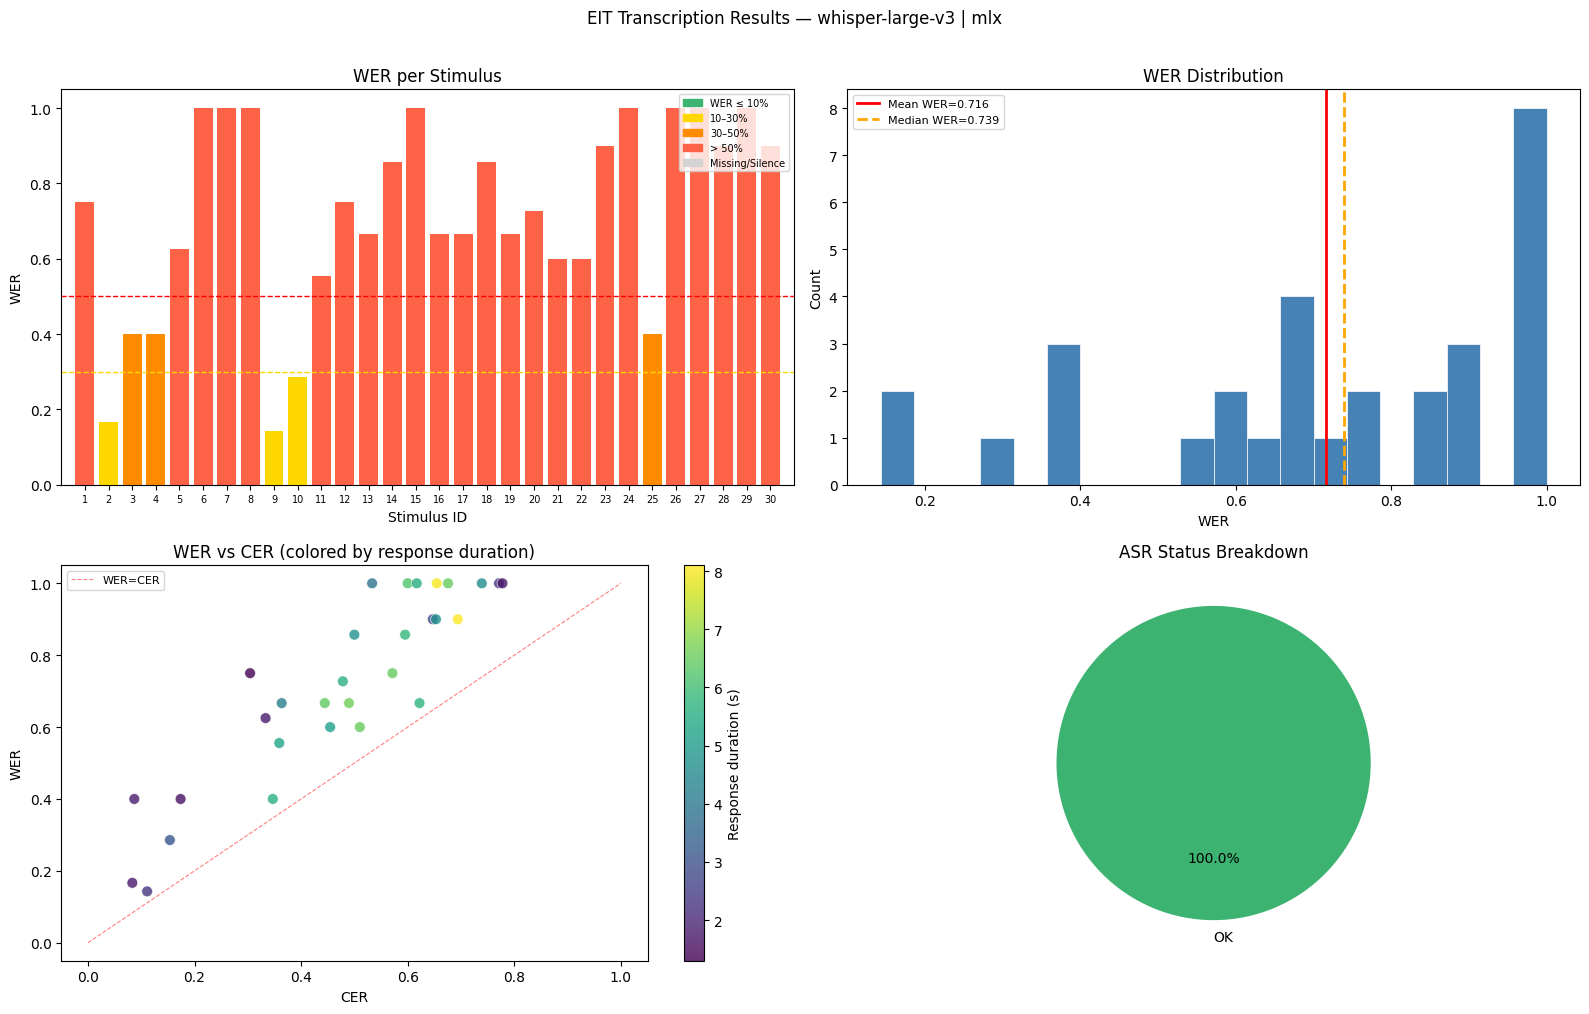

In [13]:
def plot_wer_overview(df, output_path=None):
    """Four-panel summary plot for transcription results."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    scored = df[df['asr_status'] == 'OK'].dropna(subset=['wer', 'cer'])

    # ── 1: WER per stimulus (bar chart) ────────────────────────────────
    ax = axes[0, 0]
    all_ids = range(1, 31)
    wer_by_id = {int(r['stimulus_id']): r['wer']
                  for _, r in df.iterrows() if pd.notna(r.get('wer'))}
    bar_vals   = [wer_by_id.get(i, None) for i in all_ids]
    bar_colors = []
    for v in bar_vals:
        if v is None:      bar_colors.append('lightgray')
        elif v <= 0.1:     bar_colors.append('mediumseagreen')
        elif v <= 0.3:     bar_colors.append('gold')
        elif v <= 0.5:     bar_colors.append('darkorange')
        else:              bar_colors.append('tomato')

    ax.bar(list(all_ids),
           [v if v is not None else 0 for v in bar_vals],
           color=bar_colors, edgecolor='none', width=0.8)
    ax.axhline(0.5, color='red',  ls='--', lw=1, label='WER=50%')
    ax.axhline(0.3, color='gold', ls='--', lw=1, label='WER=30%')
    ax.set(xlabel='Stimulus ID', ylabel='WER', title='WER per Stimulus',
           xlim=(0, 31), ylim=(0, 1.05))
    ax.set_xticks(range(1, 31))
    ax.tick_params(axis='x', labelsize=7)
    ax.legend(fontsize=8)
    # Color legend
    legend_patches = [
        mpatches.Patch(color='mediumseagreen', label='WER ≤ 10%'),
        mpatches.Patch(color='gold',           label='10–30%'),
        mpatches.Patch(color='darkorange',     label='30–50%'),
        mpatches.Patch(color='tomato',         label='> 50%'),
        mpatches.Patch(color='lightgray',      label='Missing/Silence'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=7)

    # ── 2: WER histogram ─────────────────────────────────────────────
    ax2 = axes[0, 1]
    if len(scored):
        ax2.hist(scored['wer'], bins=20, color='steelblue',
                 edgecolor='white', linewidth=0.5)
        ax2.axvline(scored['wer'].mean(), color='red', lw=2,
                    label=f"Mean WER={scored['wer'].mean():.3f}")
        ax2.axvline(scored['wer'].median(), color='orange', lw=2, ls='--',
                    label=f"Median WER={scored['wer'].median():.3f}")
        ax2.set(xlabel='WER', ylabel='Count', title='WER Distribution')
        ax2.legend(fontsize=8)

    # ── 3: WER vs CER scatter ─────────────────────────────────────────
    ax3 = axes[1, 0]
    if len(scored):
        sc = ax3.scatter(scored['cer'], scored['wer'],
                          c=scored['response_duration'],
                          cmap='viridis', s=60, alpha=0.8, edgecolors='white', lw=0.5)
        plt.colorbar(sc, ax=ax3, label='Response duration (s)')
        ax3.plot([0, 1], [0, 1], 'r--', lw=0.8, alpha=0.5, label='WER=CER')
        ax3.set(xlabel='CER', ylabel='WER', title='WER vs CER (colored by response duration)',
                xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
        ax3.legend(fontsize=8)

    # ── 4: ASR status breakdown ────────────────────────────────────────
    ax4 = axes[1, 1]
    status_counts = df['asr_status'].value_counts()
    status_colors = {'OK': 'mediumseagreen', 'MISSING': 'lightgray',
                     'SILENCE': 'steelblue', 'EMPTY': 'tomato'}
    colors = [status_colors.get(s, 'gray') for s in status_counts.index]
    ax4.pie(status_counts.values, labels=status_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax4.set_title('ASR Status Breakdown')

    plt.suptitle(f'EIT Transcription Results — whisper-{MODEL_SIZE} | {ACTIVE_BACKEND}',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
    plt.show()


plot_wer_overview(transcription_df,
                   output_path=OUTPUT_DIR / '01_wer_overview.png')

Saved: eit_output_v3/038012_2A_preprocessed/transcriptions/02_transcription_detail.png


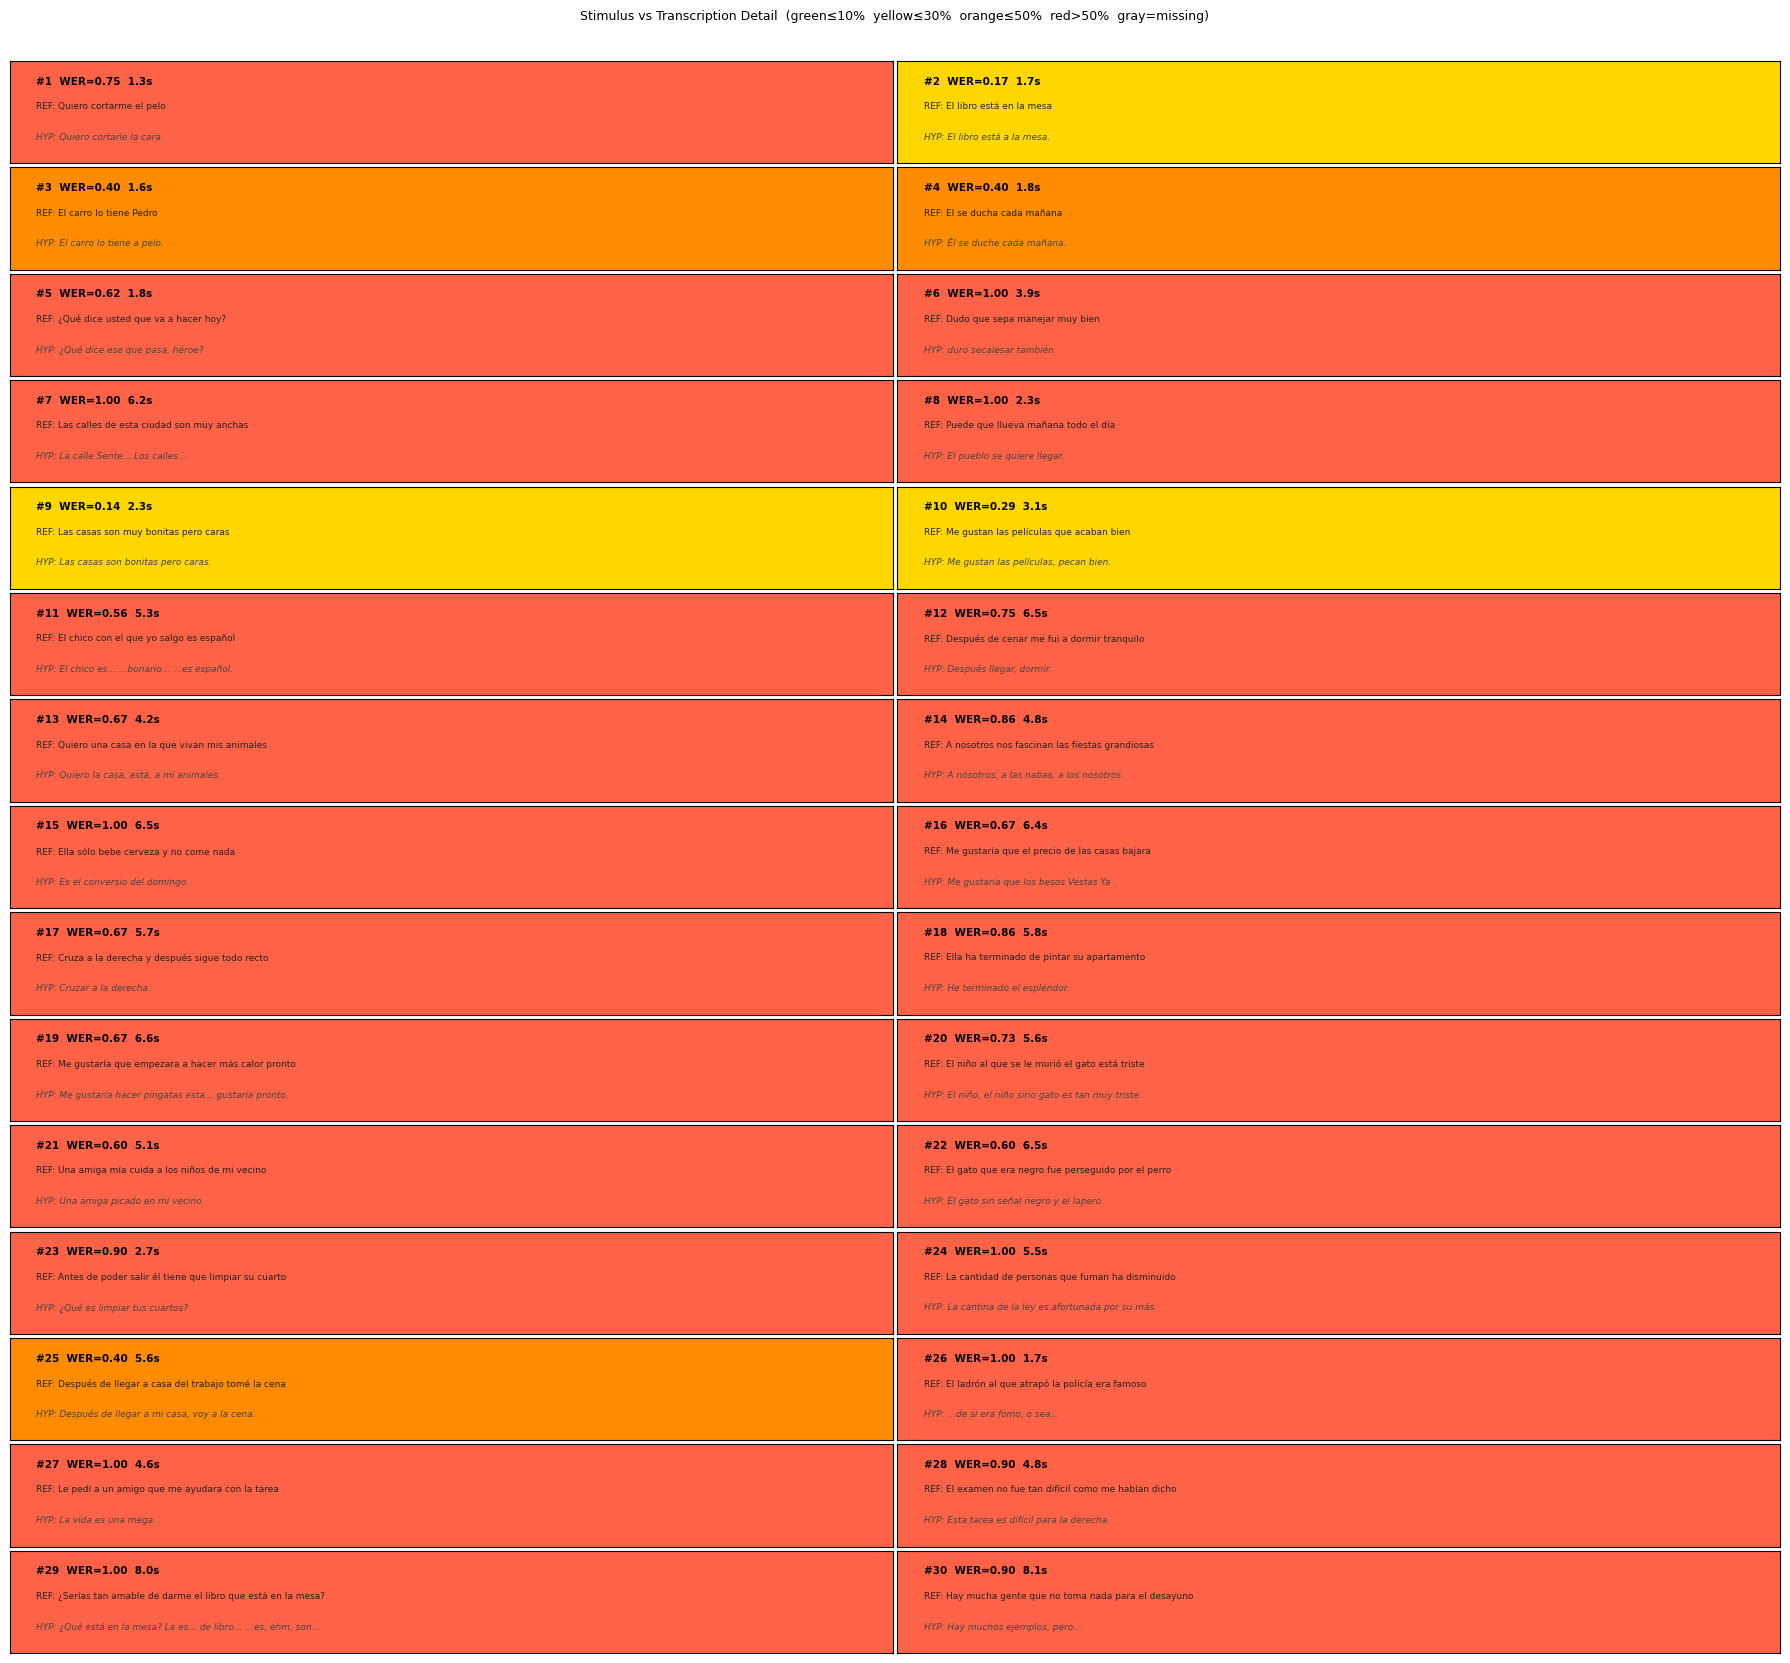

In [14]:
def plot_transcription_detail(df, output_path=None):
    """Side-by-side stimulus vs transcription for all 30 slots."""
    n_cols = 2
    n_rows = 15  # 30 pairs / 2 columns
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(18, n_rows * 1.1))
    axes_flat = axes.flatten()

    wer_colors = lambda w: (
        'mediumseagreen' if w is not None and w <= 0.1 else
        'gold'           if w is not None and w <= 0.3 else
        'darkorange'     if w is not None and w <= 0.5 else
        'tomato'         if w is not None else
        'lightgray'
    )

    for idx, row in df.iterrows():
        ax    = axes_flat[idx]
        sid   = int(row['stimulus_id'])
        wer   = row.get('wer')
        color = wer_colors(wer)

        # Colored background
        ax.set_facecolor(color)
        ax.set_alpha(0.15)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])

        wer_str  = f"WER={wer:.2f}" if wer is not None else row['asr_status']
        dur_str  = f"{row['response_duration']:.1f}s" if pd.notna(row.get('response_duration')) else ''
        ref_text = row['stimulus_text']
        hyp_text = row.get('transcription', '') or '[no transcription]'

        ax.text(0.03, 0.85, f"#{sid}  {wer_str}  {dur_str}",
                transform=ax.transAxes, fontsize=7.5, fontweight='bold', va='top')
        ax.text(0.03, 0.60, f"REF: {ref_text}",
                transform=ax.transAxes, fontsize=6.5, va='top', color='#222',
                wrap=True)
        ax.text(0.03, 0.30, f"HYP: {hyp_text}",
                transform=ax.transAxes, fontsize=6.5, va='top', color='#444',
                style='italic', wrap=True)

    # Hide unused
    for j in range(len(df), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle('Stimulus vs Transcription Detail  '
                 '(green≤10%  yellow≤30%  orange≤50%  red>50%  gray=missing)',
                 fontsize=9, y=1.005)
    plt.tight_layout(h_pad=0.3, w_pad=0.3)
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches='tight')
        print(f"Saved: {output_path}")
    plt.show()


plot_transcription_detail(transcription_df,
                           output_path=OUTPUT_DIR / '02_transcription_detail.png')

---
## Section 12 — Export Results

In [15]:
# ── CSV export ────────────────────────────────────────────────────────────
csv_cols = [
    'stimulus_id', 'stimulus_text', 'stimulus_norm',
    'transcription', 'transcription_norm',
    'wer', 'cer', 'n_ref_words', 'n_hyp_words',
    'response_start', 'response_end', 'response_duration',
    'no_speech_prob', 'asr_status', 'backend', 'elapsed_s', 'response_file'
]

csv_path = OUTPUT_DIR / 'transcriptions.csv'
transcription_df[csv_cols].to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"CSV saved: {csv_path}")


# ── XLSX export with color-coded WER ─────────────────────────────────────
try:
    from openpyxl import Workbook
    from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    def wer_to_hex(wer):
        if wer is None or (isinstance(wer, float) and np.isnan(wer)):
            return 'D3D3D3'  # gray
        if wer <= 0.10: return '90EE90'  # light green
        if wer <= 0.30: return 'FFD700'  # gold
        if wer <= 0.50: return 'FFA500'  # orange
        return 'FF6961'                   # red

    wb  = Workbook()
    ws  = wb.active
    ws.title = 'Transcriptions'

    export_cols = ['stimulus_id','stimulus_text','transcription',
                   'wer','cer','n_ref_words','n_hyp_words',
                   'response_duration','asr_status']

    # Header row
    header_fill = PatternFill(fill_type='solid', fgColor='1F4E79')
    header_font = Font(bold=True, color='FFFFFF')
    for col_idx, col_name in enumerate(export_cols, 1):
        cell = ws.cell(row=1, column=col_idx, value=col_name.upper().replace('_',' '))
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center')

    # Data rows
    thin = Side(style='thin', color='CCCCCC')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for row_idx, row in transcription_df[export_cols].iterrows():
        fill_color = wer_to_hex(row.get('wer'))
        row_fill   = PatternFill(fill_type='solid', fgColor=fill_color)

        for col_idx, val in enumerate(row, 1):
            cell = ws.cell(row=row_idx + 2, column=col_idx, value=val)
            cell.border = border
            cell.alignment = Alignment(wrap_text=True, vertical='top')
            # Color WER and CER columns
            if export_cols[col_idx - 1] in ('wer', 'cer'):
                cell.fill = row_fill
                if isinstance(val, float):
                    cell.number_format = '0.0%'

    # Column widths
    col_widths = [6, 45, 45, 8, 8, 8, 8, 10, 12]
    for i, w in enumerate(col_widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    # Freeze header
    ws.freeze_panes = 'A3'

    # Summary sheet
    ws2 = wb.create_sheet('Summary')
    ok_scored = transcription_df[transcription_df['asr_status']=='OK'].dropna(subset=['wer'])
    summary_data = [
        ('Recording',    Path(SEGMENTS_CSV).parent.name),
        ('Model',        f'whisper-{MODEL_SIZE}'),
        ('Backend',      ACTIVE_BACKEND),
        ('Language',     LANGUAGE),
        ('Total stimuli', len(transcription_df)),
        ('Transcribed',  len(ok_scored)),
        ('Missing',      (transcription_df['asr_status']=='MISSING').sum()),
        ('Silence',      (transcription_df['asr_status']=='SILENCE').sum()),
        ('Mean WER',     f"{ok_scored['wer'].mean()*100:.1f}%" if len(ok_scored) else 'N/A'),
        ('Median WER',   f"{ok_scored['wer'].median()*100:.1f}%" if len(ok_scored) else 'N/A'),
        ('Mean CER',     f"{ok_scored['cer'].mean()*100:.1f}%" if len(ok_scored) else 'N/A'),
    ]
    for r, (k, v) in enumerate(summary_data, 1):
        ws2.cell(row=r, column=1, value=k).font = Font(bold=True)
        ws2.cell(row=r, column=2, value=str(v))
    ws2.column_dimensions['A'].width = 20
    ws2.column_dimensions['B'].width = 25

    xlsx_path = OUTPUT_DIR / 'transcriptions.xlsx'
    wb.save(str(xlsx_path))
    print(f"XLSX saved: {xlsx_path}")

except Exception as e:
    print(f"XLSX export skipped: {e}")


# ── Word timestamps JSON ──────────────────────────────────────────────────
if WORD_TIMESTAMPS:
    word_ts_records = []
    for _, row in transcription_df.iterrows():
        try:
            words = json.loads(row.get('word_timestamps', '[]') or '[]')
            for w in words:
                w['stimulus_id'] = int(row['stimulus_id'])
                word_ts_records.append(w)
        except Exception:
            pass

    if word_ts_records:
        word_ts_df = pd.DataFrame(word_ts_records)
        word_ts_path = OUTPUT_DIR / 'word_timestamps.csv'
        word_ts_df.to_csv(word_ts_path, index=False, encoding='utf-8-sig')
        print(f"Word timestamps: {word_ts_path}")

print(f"\nAll exports saved to: {OUTPUT_DIR}")

CSV saved: eit_output_v3/038012_2A_preprocessed/transcriptions/transcriptions.csv
XLSX saved: eit_output_v3/038012_2A_preprocessed/transcriptions/transcriptions.xlsx
Word timestamps: eit_output_v3/038012_2A_preprocessed/transcriptions/word_timestamps.csv

All exports saved to: eit_output_v3/038012_2A_preprocessed/transcriptions


---
## Section 13 — Diagnostic Report

In [16]:
ok_df      = transcription_df[transcription_df['asr_status'] == 'OK']
scored_df  = ok_df.dropna(subset=['wer'])

print("═" * 65)
print("  EIT TRANSCRIPTION PIPELINE — FINAL REPORT")
print("═" * 65)
print(f"  Recording      : {Path(SEGMENTS_CSV).parent.name}")
print(f"  Model          : whisper-{MODEL_SIZE}")
print(f"  Backend        : {ACTIVE_BACKEND} ({CHIP})")
print(f"  Language       : {LANGUAGE}")
print()
print(f"  Total stimuli  : {len(transcription_df)}")
print(f"  Transcribed    : {len(ok_df)}")
print(f"  Missing (seg.) : {(transcription_df['asr_status']=='MISSING').sum()}")
print(f"  Silence        : {(transcription_df['asr_status']=='SILENCE').sum()}")
print()
if len(scored_df):
    print(f"  Mean WER       : {scored_df['wer'].mean()*100:.2f}%")
    print(f"  Median WER     : {scored_df['wer'].median()*100:.2f}%")
    print(f"  Mean CER       : {scored_df['cer'].mean()*100:.2f}%")
    print()
    # Best and worst responses
    best  = scored_df.loc[scored_df['wer'].idxmin()]
    worst = scored_df.loc[scored_df['wer'].idxmax()]
    print(f"  Best response  (#{ int(best['stimulus_id'])} WER={best['wer']:.3f}):")
    print(f"    REF: {best['stimulus_text']}")
    print(f"    HYP: {best['transcription']}")
    print()
    print(f"  Worst response (#{ int(worst['stimulus_id'])} WER={worst['wer']:.3f}):")
    print(f"    REF: {worst['stimulus_text']}")
    print(f"    HYP: {worst['transcription']}")
print()
print(f"  Outputs        : {OUTPUT_DIR}")
print("═" * 65)

# Full results table
display(transcription_df[['stimulus_id','stimulus_text','transcription',
                            'wer','cer','asr_status']].to_string(index=False))

═════════════════════════════════════════════════════════════════
  EIT TRANSCRIPTION PIPELINE — FINAL REPORT
═════════════════════════════════════════════════════════════════
  Recording      : 038012_2A_preprocessed
  Model          : whisper-large-v3
  Backend        : mlx (apple_silicon)
  Language       : es

  Total stimuli  : 30
  Transcribed    : 30
  Missing (seg.) : 0
  Silence        : 0

  Mean WER       : 71.61%
  Median WER     : 73.87%
  Mean CER       : 47.82%

  Best response  (#9 WER=0.143):
    REF: Las casas son muy bonitas pero caras
    HYP: Las casas son bonitas pero caras.

  Worst response (#6 WER=1.000):
    REF: Dudo que sepa manejar muy bien
    HYP: duro secalesar también

  Outputs        : eit_output_v3/038012_2A_preprocessed/transcriptions
═════════════════════════════════════════════════════════════════


' stimulus_id                                             stimulus_text                                                 transcription    wer    cer asr_status\n           1                                   Quiero cortarme el pelo                                      Quiero cortarle la cara. 0.7500 0.3043         OK\n           2                                  El libro está en la mesa                                      El libro está a la mesa. 0.1667 0.0833         OK\n           3                                   El carro lo tiene Pedro                                     El carro lo tiene a pelo. 0.4000 0.1739         OK\n           4                                   El se ducha cada mañana                                      Él se duche cada mañana. 0.4000 0.0870         OK\n           5                       ¿Qué dice usted que va a hacer hoy?                                ¿Qué dice ese que pasa, héroe? 0.6250 0.3333         OK\n           6                            Dudo 

---
## Section 14 — Batch Mode: All 4 Recordings

In [17]:
# List of segments CSVs from all recordings
SEGMENTS_CSV_LIST = [
    "eit_output_v3/038015_1A_preprocessed/segments.csv",
    "eit_output_v3/038012_2A_preprocessed/segments.csv",
    "eit_output_v3/038011_1A_preprocessed/segments.csv",
    "eit_output_v3/038010_2A_preprocessed/segments.csv",
]

all_results = []

for csv_path in SEGMENTS_CSV_LIST:
    if not os.path.exists(csv_path):
        print(f"SKIP (not found): {csv_path}")
        continue

    print(f"\n{'='*55}")
    print(f"Processing: {Path(csv_path).parent.name}")
    print(f"{'='*55}")

    try:
        segs_df  = load_segments(csv_path)
        to_trans = segs_df[segs_df['status']=='OK'].copy().reset_index(drop=True)
        miss_seg = segs_df[segs_df['status']=='MISSING'].copy()

        out_dir  = Path(csv_path).parent / 'transcriptions'
        out_dir.mkdir(parents=True, exist_ok=True)

        ckpt_path = out_dir / 'transcription_checkpoint.json'
        ckpt      = load_checkpoint(ckpt_path)

        trans_df  = run_batch_transcription(
            to_trans, model, ACTIVE_BACKEND, ckpt, ckpt_path, out_dir
        )

        if not miss_seg.empty:
            miss_recs = [_make_missing_record(r) for _, r in miss_seg.iterrows()]
            trans_df  = pd.concat([trans_df, pd.DataFrame(miss_recs)], ignore_index=True)

        trans_df = trans_df.sort_values('stimulus_id').reset_index(drop=True)
        trans_df.to_csv(out_dir / 'transcriptions.csv', index=False, encoding='utf-8-sig')

        # Summary
        scored = trans_df[trans_df['asr_status']=='OK'].dropna(subset=['wer'])
        summary = {
            'recording'   : Path(csv_path).parent.name,
            'transcribed' : len(scored),
            'missing'     : (trans_df['asr_status']=='MISSING').sum(),
            'mean_wer'    : round(scored['wer'].mean(), 4) if len(scored) else None,
            'mean_cer'    : round(scored['cer'].mean(), 4) if len(scored) else None,
        }
        all_results.append(summary)
        print(f"  Done: {summary['transcribed']}/30 transcribed, Mean WER={summary['mean_wer']}")

    except Exception as e:
        print(f"  ERROR: {e}")
        all_results.append({'recording': Path(csv_path).parent.name, 'error': str(e)})

# Batch summary table
if all_results:
    batch_summary = pd.DataFrame(all_results)
    print(f"\n{'='*55}")
    print("BATCH SUMMARY")
    print(f"{'='*55}")
    print(batch_summary.to_string(index=False))

    batch_summary.to_csv(
        Path(SEGMENTS_CSV_LIST[0]).parent.parent / 'batch_transcription_summary.csv',
        index=False
    )


Processing: 038015_1A_preprocessed
Loaded: eit_output_v3/038015_1A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0
Checkpoint loaded: 30 previously completed segments.


Transcribing: 100%|██████████| 30/30 [00:00<00:00, 45889.54it/s]



Total transcription time: 0.0s (0.00s/seg avg)
  Done: 30/30 transcribed, Mean WER=0.2822

Processing: 038012_2A_preprocessed
Loaded: eit_output_v3/038012_2A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0
Checkpoint loaded: 30 previously completed segments.


Transcribing: 100%|██████████| 30/30 [00:00<00:00, 60262.99it/s]



Total transcription time: 0.0s (0.00s/seg avg)
  Done: 30/30 transcribed, Mean WER=0.8864

Processing: 038011_1A_preprocessed
Loaded: eit_output_v3/038011_1A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0
Checkpoint loaded: 30 previously completed segments.


Transcribing: 100%|██████████| 30/30 [00:00<00:00, 57587.70it/s]



Total transcription time: 0.0s (0.00s/seg avg)
  Done: 30/30 transcribed, Mean WER=0.4185

Processing: 038010_2A_preprocessed
Loaded: eit_output_v3/038010_2A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0
Checkpoint loaded: 30 previously completed segments.


Transcribing: 100%|██████████| 30/30 [00:00<00:00, 62632.71it/s]


Total transcription time: 0.0s (0.00s/seg avg)
  Done: 30/30 transcribed, Mean WER=0.5071

BATCH SUMMARY
             recording  transcribed  missing  mean_wer  mean_cer
038015_1A_preprocessed           30        0    0.2822    0.1751
038012_2A_preprocessed           30        0    0.8864    0.6518
038011_1A_preprocessed           30        0    0.4185    0.2787
038010_2A_preprocessed           30        0    0.5071    0.3901


---
## Appendix — Calibration & Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| High WER on all segments | Wrong language / no language forced | Confirm `LANGUAGE='es'`, lower `TEMPERATURE` |
| Many SILENCE flags | `NO_SPEECH_THRESH` too low | Raise to `0.7` or `0.8` |
| Missing initial/final words | Insufficient padding | Raise `AUDIO_PAD_S` to `0.3` |
| Slow transcription | Using OpenAI backend on Intel | Install `pywhispercpp`; on M-chip install `mlx-whisper` |
| MLX model download fails | No internet / wrong model ID | Check `MLX_MODEL_MAP`, use `openai` fallback |
| Transcription includes previous segment | `CONDITION_ON_PREV=True` | Keep `False` for independent clips |
| Hallucinated text on silence | Whisper hallucinates on short silence | Raise `NO_SPEECH_THRESH` to `0.7` |

### Quick Re-run Cell (adjust parameters without reloading model)

In [ ]:
# ── Retranscribe single segment to test parameters ──────────────────────
STIMULUS_ID_TO_TEST = 1       # Change to any stimulus ID
TEST_TEMPERATURE    = 0.0
TEST_BEAM_SIZE      = 5

test_row = segments_df[segments_df['stimulus_id'] == STIMULUS_ID_TO_TEST].iloc[0]
test_file = str(test_row['response_file'])

if os.path.exists(test_file):
    result = transcribe(
        test_file, model, ACTIVE_BACKEND,
        temperature=TEST_TEMPERATURE,
        beam_size=TEST_BEAM_SIZE
    )
    scores = score_transcription(result['text'], test_row['stimulus_text'])

    print(f"Stimulus #{STIMULUS_ID_TO_TEST}")
    print(f"  REF : {test_row['stimulus_text']}")
    print(f"  HYP : {result['text']}")
    print(f"  WER : {scores['wer']:.4f}")
    print(f"  CER : {scores['cer']:.4f}")
    print(f"  Time: {result['elapsed_s']:.2f}s")
    if result.get('words'):
        print(f"  Words: {result['words']}")
else:
    print(f"File not found: {test_file}")